In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import TensorBoard
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import os
import datetime
import json
import joblib

In [2]:
os.makedirs("results", exist_ok=True)
os.makedirs("logs/fit/LSTM", exist_ok=True)

In [3]:
log_dir = "logs/fit/LSTM/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [4]:
df = pd.read_csv("../day_approach_maskedID_timeseries.csv")
df = df.drop(columns=["Athlete ID", "Date"])
df.fillna(df.median(), inplace=True)

In [6]:
n_timesteps = 7
n_features = int(df.shape[1] / n_timesteps)  

X_raw = df.drop(columns=["injury"]).values
y = df["injury"].values

X = X_raw.reshape(-1, n_timesteps, n_features)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

class_weights = class_weight.compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

In [7]:
model = keras.Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(n_timesteps, n_features)),  
    layers.Dropout(0.3),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

d:\Anaconda\envs\SAT5114\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict,
    callbacks=[tensorboard_callback],
    verbose=1
)

Epoch 1/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6276 - loss: 0.6960 - val_accuracy: 0.6997 - val_loss: 0.6239
Epoch 2/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5562 - loss: 0.6721 - val_accuracy: 0.4870 - val_loss: 0.7200
Epoch 3/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5051 - loss: 0.6852 - val_accuracy: 0.5735 - val_loss: 0.6336
Epoch 4/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5157 - loss: 0.6916 - val_accuracy: 0.4961 - val_loss: 0.6453
Epoch 5/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5417 - loss: 0.6368 - val_accuracy: 0.4235 - val_loss: 0.7523
Epoch 6/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5245 - loss: 0.6572 - val_accuracy: 0.5722 - val_loss: 0.6296
Epoch 7/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5400 - loss: 0.6508 - val_accuracy: 0.5849 - val_loss: 0.6822
Epoch 8/50
1070/1070 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5845 - loss: 0.6450 - 

In [9]:
model.save("results/LSTM/lstm_injury_prediction_model.h5")
joblib.dump(scaler, "results/LSTM/scaler.pkl")

with open("results/LSTM/training_history.json", "w") as f:
    json.dump(history.history, f)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_prob))
print("Classification Report:\n", classification_report(y_test, y_pred))

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9436520925882628
AUC-ROC: 0.541121778409914
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97      8437
           1       0.03      0.09      0.04       117

    accuracy                           0.94      8554
   macro avg       0.51      0.52      0.51      8554
weighted avg       0.97      0.94      0.96      8554



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

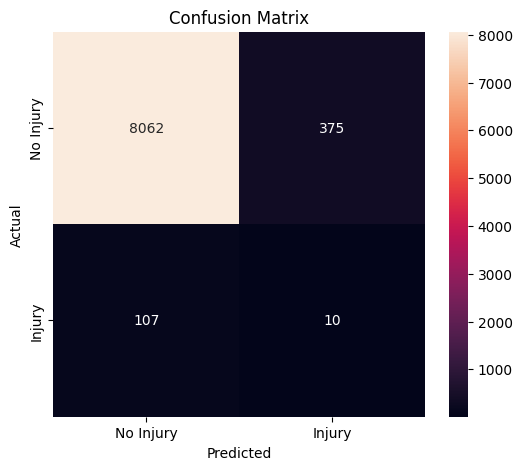

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["No Injury", "Injury"], yticklabels=["No Injury", "Injury"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()